
--- DATA PREVIEW ---
      timestamp    amount0    amount1     ratio
0  1.610000e+09   4.967142  87.409420  0.056826
1  1.610036e+09   2.624300  95.211085  0.027563
2  1.610072e+09  14.484335  68.554570  0.211282
3  1.610108e+09  27.225394  83.926139  0.324397
4  1.610144e+09  13.621941  73.768951  0.184657


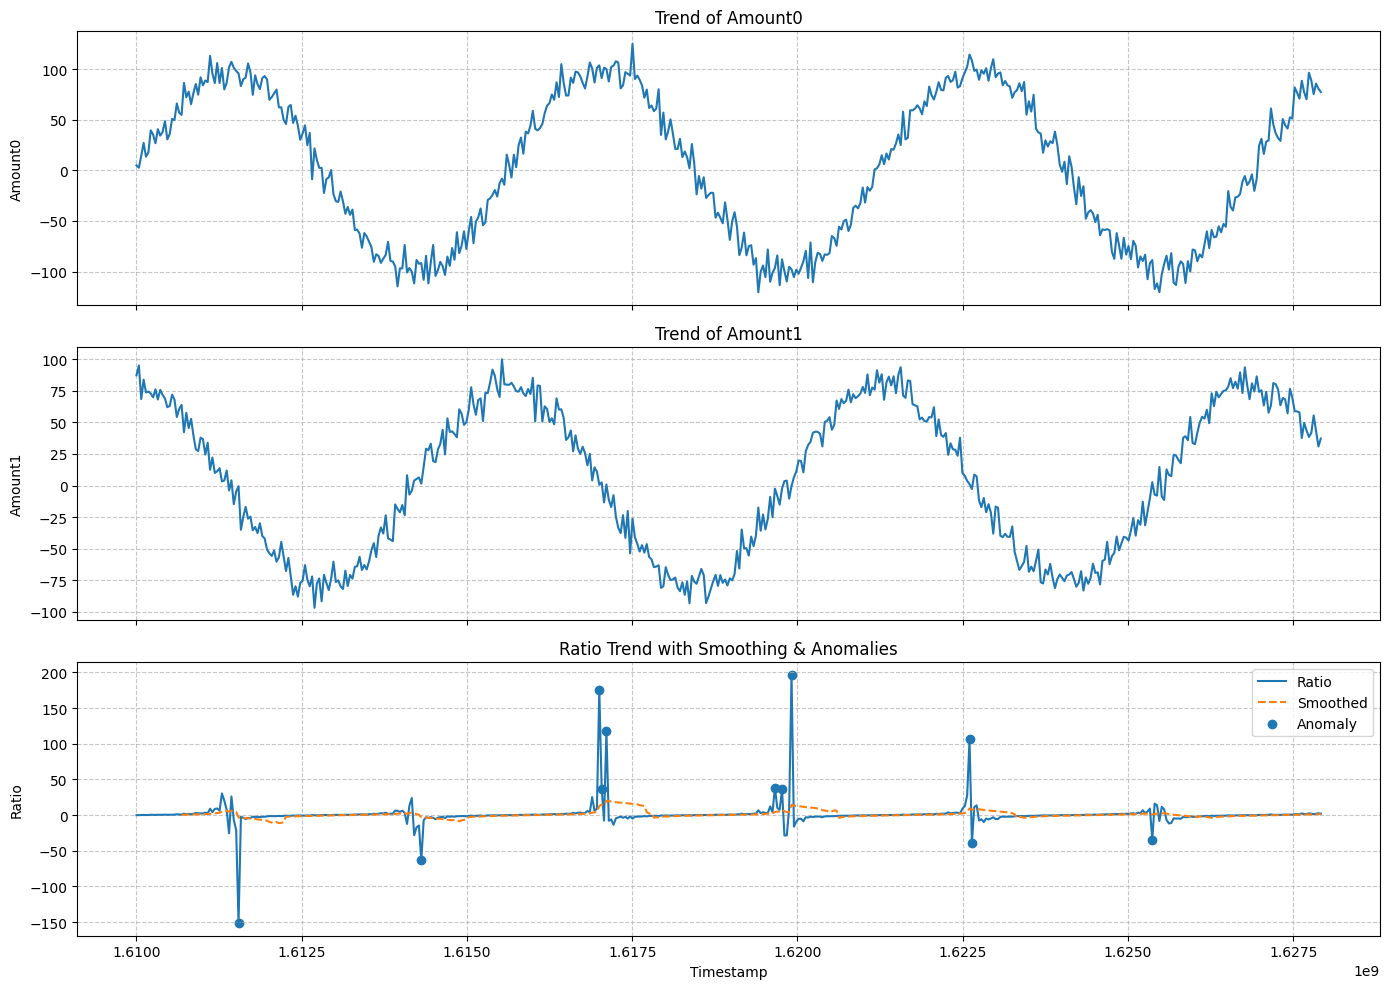

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- MOCK FUNCTION (Replace with your real API logic if needed) ---
def generate_digital_twin_data(pair_addr, start, end):
    np.random.seed(42)

    timestamps = np.linspace(start, end, 500)

    # Simulated token values (you can replace this with real data)
    amount0 = np.sin(np.linspace(0, 20, 500)) * 100 + np.random.normal(0, 10, 500)
    amount1 = np.cos(np.linspace(0, 20, 500)) * 80 + np.random.normal(0, 8, 500)

    df = pd.DataFrame({
        'timestamp': timestamps,
        'amount0': amount0,
        'amount1': amount1
    })

    # Feature Engineering: Ratio
    df['ratio'] = df['amount0'] / (df['amount1'] + 1e-18)

    return df


# --- CONFIGURATION ---
PAIR_ADDR = "0x8ae720a71622e824f576b4a8c03031066548a3b1"
START = 1610000000
END = 1627918115

# --- EXECUTION ---
df_final = generate_digital_twin_data(PAIR_ADDR, START, END)

if not df_final.empty:
    print("\n--- DATA PREVIEW ---")
    print(df_final.head())

    # --- ADDITIONAL ANALYSIS ---
    # Rolling average (trend smoothing)
    df_final['ratio_smooth'] = df_final['ratio'].rolling(window=20).mean()

    # Anomaly detection (simple statistical threshold)
    mean = df_final['ratio'].mean()
    std = df_final['ratio'].std()
    df_final['anomaly'] = abs(df_final['ratio'] - mean) > 2 * std

    # --- SUBPLOT VISUALIZATION ---
    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Subplot 1: Amount0
    axs[0].plot(df_final['timestamp'], df_final['amount0'])
    axs[0].set_title('Trend of Amount0')
    axs[0].set_ylabel('Amount0')
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # Subplot 2: Amount1
    axs[1].plot(df_final['timestamp'], df_final['amount1'])
    axs[1].set_title('Trend of Amount1')
    axs[1].set_ylabel('Amount1')
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # Subplot 3: Ratio + Smoothed + Anomalies
    axs[2].plot(df_final['timestamp'], df_final['ratio'], label='Ratio')
    axs[2].plot(df_final['timestamp'], df_final['ratio_smooth'], linestyle='--', label='Smoothed')

    # Highlight anomalies
    anomalies = df_final[df_final['anomaly']]
    axs[2].scatter(anomalies['timestamp'], anomalies['ratio'], label='Anomaly')

    axs[2].set_title('Ratio Trend with Smoothing & Anomalies')
    axs[2].set_xlabel('Timestamp')
    axs[2].set_ylabel('Ratio')
    axs[2].legend()
    axs[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

else:
    print("No data to display.")